# EDA and Import

In [ ]:
# Load dataset and inspect basic structure
import pandas as pd

train = pd.read_csv(r"c:\Users\danma\Downloads\GiveMeSomeCredit\cs-training.csv")

### Train EDA

In [ ]:
# Display first rows to understand variables
train.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
train.shape

(150000, 12)

In [ ]:
# Check missing values in each column
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [ ]:
# Check summary statistics to identify distributions and outliers
train.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


### Prep

In [ ]:
# Remove the extra index column
train = train.drop(columns=["Unnamed: 0"])

In [ ]:
# Fill missing values in NumberOfDependents with median
train["NumberOfDependents"].fillna(train["NumberOfDependents"].median(), inplace=True)

C:\Users\danma\AppData\Local\Temp\ipykernel_26308\1145248901.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train["NumberOfDependents"].fillna(train["NumberOfDependents"].median(), inplace=True)


In [ ]:
# Fill missing values in MonthlyIncome with median
train["MonthlyIncome"].fillna(train["MonthlyIncome"].median(), inplace=True)

C:\Users\danma\AppData\Local\Temp\ipykernel_26308\2283236440.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train["MonthlyIncome"].fillna(train["MonthlyIncome"].median(), inplace=True)


In [ ]:
# Rename columns for easier access
train = train.rename(columns={
    "SeriousDlqin2yrs": "default",
    "RevolvingUtilizationOfUnsecuredLines": "utilization",
    "age": "age",
    "NumberOfTime30-59DaysPastDueNotWorse": "late_30_59",
    "DebtRatio": "debt_ratio",
    "MonthlyIncome": "income",
    "NumberOfOpenCreditLinesAndLoans": "credit_lines",
    "NumberOfTimes90DaysLate": "late_90",
    "NumberRealEstateLoansOrLines": "real_estate_loans",
    "NumberOfTime60-89DaysPastDueNotWorse": "late_60_89",
    "NumberOfDependents": "dependents"
})



In [ ]:
# Remove records with age less than or equal to 18 as they are not legally eligible for credit
train = train[train["age"] > 18]

In [408]:
#What percent of default is 1 and what percent is 0?
train["default"].value_counts(normalize=True)

default
0    0.93316
1    0.06684
Name: proportion, dtype: float64

## Visuals

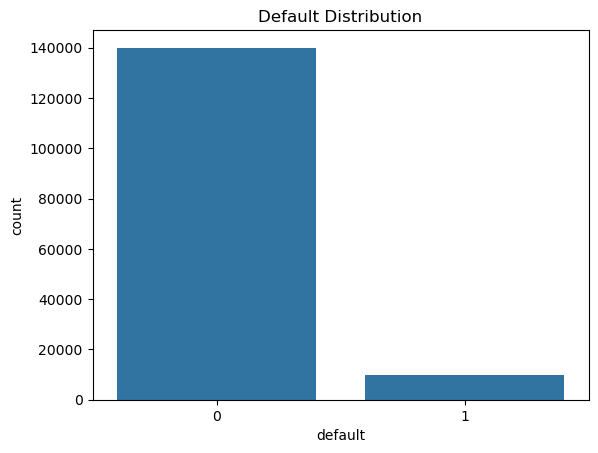

In [ ]:
# Visualize the distribution of the target variable
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="default", data=train)
plt.title("Default Distribution")
plt.show()

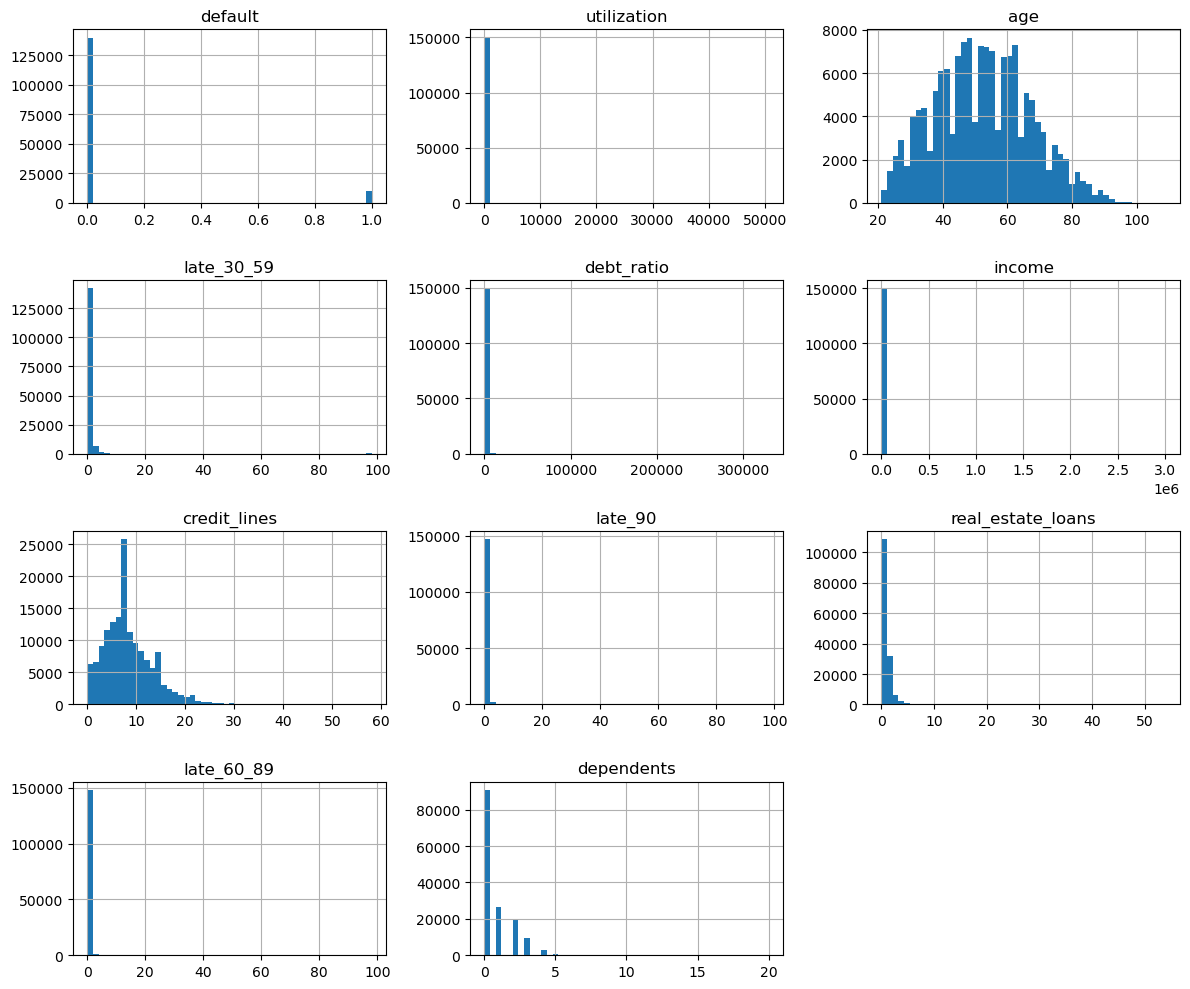

In [ ]:
# Visualize the distribution of numeric features
train.hist(figsize=(12,10), bins=50)
plt.tight_layout()
plt.show()

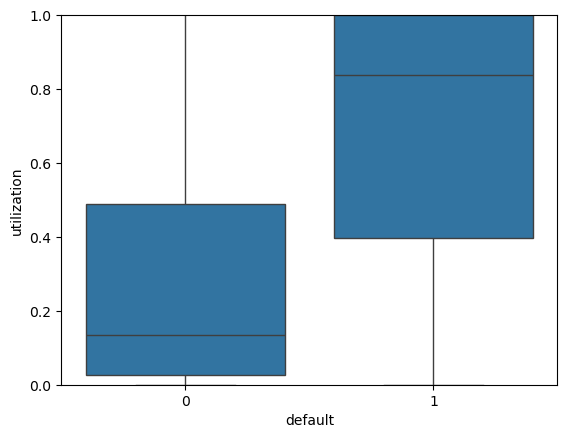

In [ ]:
# Visualize the relationship between utilization and default
sns.boxplot(x="default", y="utilization", data=train)
plt.ylim(0,1)
plt.show()

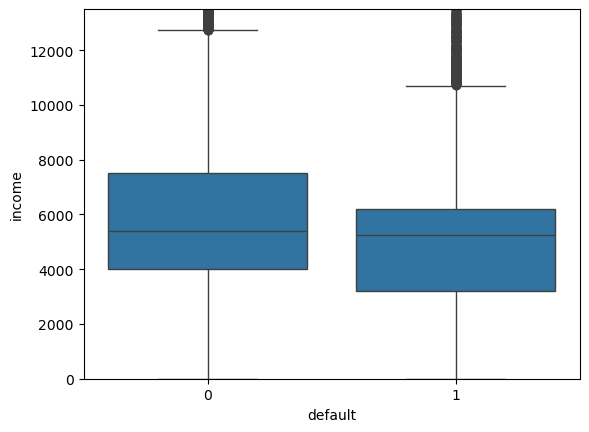

In [ ]:
# Visualize the relationship between income and default
sns.boxplot(x="default", y="income", data=train)
plt.ylim(0, train["income"].quantile(0.95))
plt.show()

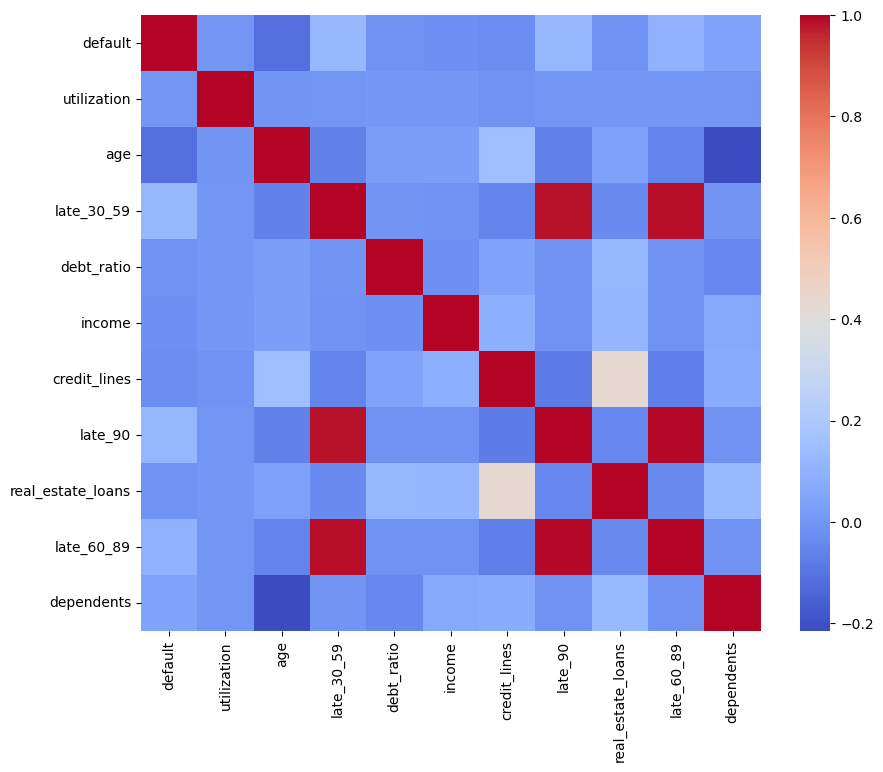

In [ ]:
# Visualize the correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(train.corr(), annot=False, cmap="coolwarm")
plt.show()

## Feature Engineer

In [ ]:
# Create a new feature for total late payments
train["total_late"] = train["late_30_59"] + train["late_60_89"] + train["late_90"]

In [ ]:
# Select features for modeling
features = [
    "utilization",
    "income",
    "debt_ratio",
    "age",
    "credit_lines",
    "total_late"
]

In [ ]:
# Prepare data for modeling
train_model = train.copy()

# Remove outliers in debt_ratio by capping at the 99th percentile
threshold = train_model["debt_ratio"].quantile(0.99)
train_model = train_model[train_model["debt_ratio"] < threshold].copy()

# Cap utilization at 1 since it represents 100% of credit used
train_model["utilization"] = train_model["utilization"].clip(0, 1)

# Prepare features and target variable
X = train_model[features].copy()
y = train_model["default"].copy()

## Modeling

### Logistic model

In [ ]:
# Split data into training and validation sets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features using StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Train a logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
# Make predictions and evaluate the model
preds = model.predict(X_val_scaled)
probs = model.predict_proba(X_val_scaled)[:, 1]

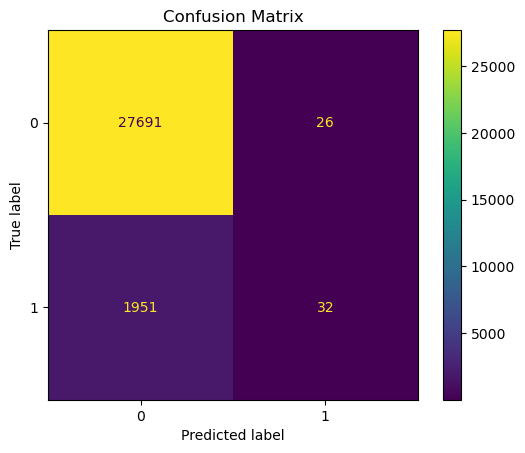

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Display confusion matrix
cm = confusion_matrix(y_val, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Print classification report
from sklearn.metrics import classification_report

print(classification_report(y_val, preds))

              precision    recall  f1-score   support

           0       0.93      1.00      0.97     27717
           1       0.55      0.02      0.03      1983

    accuracy                           0.93     29700
   macro avg       0.74      0.51      0.50     29700
weighted avg       0.91      0.93      0.90     29700



In [ ]:
# Calculate and print ROC-AUC score
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(y_val, probs)
print("ROC-AUC:", roc)

ROC-AUC: 0.7949920083235917


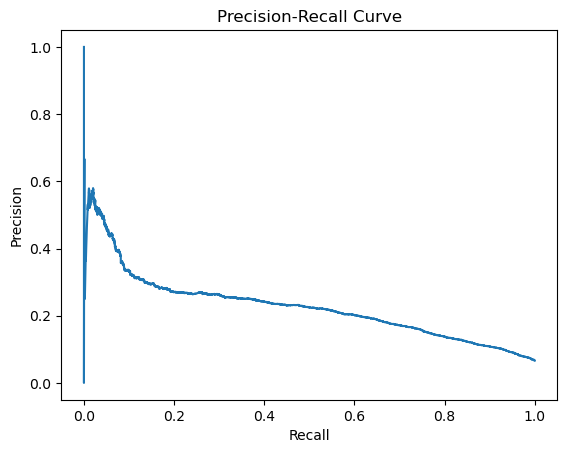

In [ ]:
# Calculate and plot Precision-Recall curve
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_val, probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
# Adjust classification threshold to 0.2 and evaluate performance
custom_preds = (probs > 0.2).astype(int)

print(classification_report(y_val, custom_preds))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94     27717
           1       0.25      0.35      0.29      1983

    accuracy                           0.89     29700
   macro avg       0.60      0.64      0.62     29700
weighted avg       0.91      0.89      0.90     29700



In [ ]:
# Analyze feature importance using coefficients from logistic regression
coef = pd.DataFrame({
    "feature": X_train.columns,
    "coef": model.coef_[0]
}).sort_values(by="coef", ascending=False)

coef

,feature,coef
0,utilization,0.979716
4,credit_lines,0.235323
5,total_late,0.091347
2,debt_ratio,-0.059590
3,age,-0.237177
1,income,-0.252763


### Binary Tree Model


In [ ]:
# Train a decision tree classifier for comparison
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
# Make predictions and evaluate the decision tree model
tree_preds = tree.predict(X_val_scaled)
tree_probs = tree.predict_proba(X_val_scaled)[:, 1]

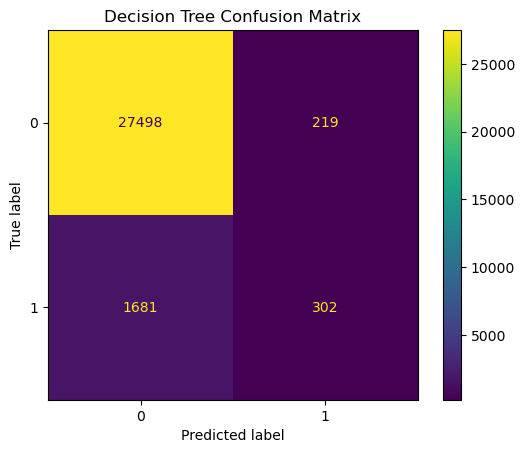

In [ ]:
# Display confusion matrix for decision tree
tree_cm = confusion_matrix(y_val, tree_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=tree_cm)
disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [ ]:
# Print classification report for decision tree
print(classification_report(y_val, tree_preds))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27717
           1       0.58      0.15      0.24      1983

    accuracy                           0.94     29700
   macro avg       0.76      0.57      0.60     29700
weighted avg       0.92      0.94      0.92     29700



In [ ]:
# Calculate and print ROC-AUC score for decision tree
print("Decision Tree ROC-AUC:", roc_auc_score(y_val, tree_probs))

Decision Tree ROC-AUC: 0.8517923237223075


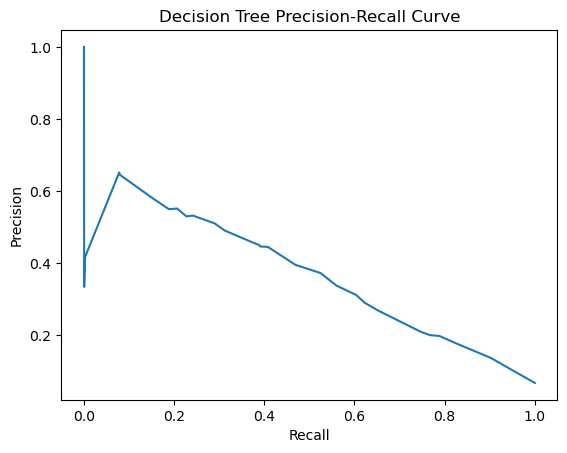

In [ ]:
# Calculate and plot Precision-Recall curve for decision tree
precision, recall, thresholds = precision_recall_curve(y_val, tree_probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Decision Tree Precision-Recall Curve")
plt.show()

In [ ]:
# Adjust classification threshold to 0.2 and evaluate performance for decision tree
tree_custom_preds = (tree_probs > 0.2).astype(int)
print(classification_report(y_val, tree_custom_preds))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95     27717
           1       0.37      0.52      0.44      1983

    accuracy                           0.91     29700
   macro avg       0.67      0.73      0.69     29700
weighted avg       0.93      0.91      0.92     29700



In [ ]:
# Analyze feature importance for decision tree
tree_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": tree.feature_importances_
}).sort_values(by="importance", ascending=False)

tree_importance

,feature,importance
5,total_late,0.793863
0,utilization,0.178349
4,credit_lines,0.012374
3,age,0.010673
2,debt_ratio,0.002732
1,income,0.002009


### Random Forest Model

In [ ]:
# Train a random forest classifier for comparison
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Make predictions and evaluate the random forest model
rf_preds = rf.predict(X_val_scaled)
rf_probs = rf.predict_proba(X_val_scaled)[:, 1]

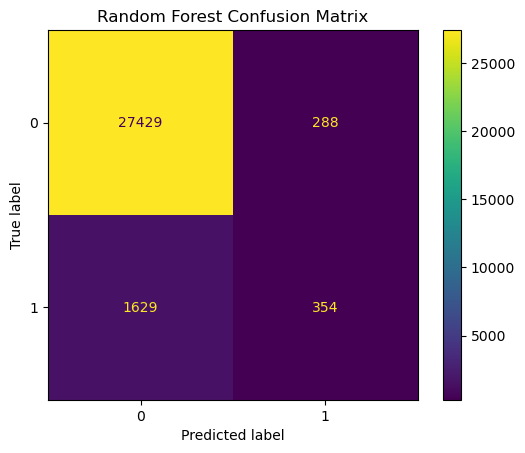

In [ ]:
# Display confusion matrix for random forest
rf_cm = confusion_matrix(y_val, rf_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
# Print classification report for random forest
print(classification_report(y_val, rf_preds))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27717
           1       0.55      0.18      0.27      1983

    accuracy                           0.94     29700
   macro avg       0.75      0.58      0.62     29700
weighted avg       0.92      0.94      0.92     29700



In [ ]:
# Calculate and print ROC-AUC score for random forest
print("Random Forest ROC-AUC:", roc_auc_score(y_val, rf_probs))

Random Forest ROC-AUC: 0.8355388246063323


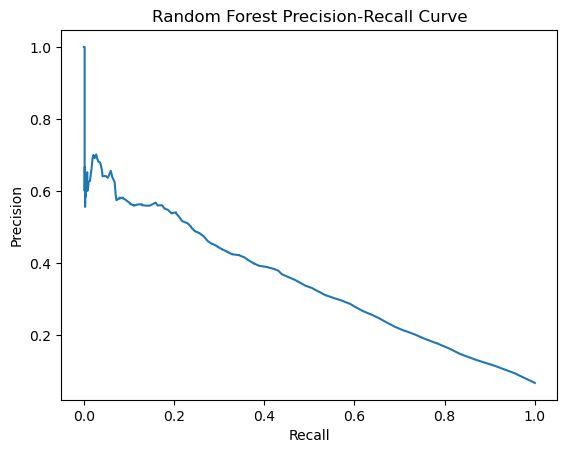

In [ ]:
# Calculate and plot Precision-Recall curve for random forest
precision, recall, thresholds = precision_recall_curve(y_val, rf_probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Random Forest Precision-Recall Curve")
plt.show()

In [ ]:
# Adjust classification threshold to 0.2 and evaluate performance for random forest
rf_custom_preds = (rf_probs > 0.2).astype(int)
print(classification_report(y_val, rf_custom_preds))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94     27717
           1       0.33      0.51      0.40      1983

    accuracy                           0.90     29700
   macro avg       0.65      0.72      0.67     29700
weighted avg       0.92      0.90      0.91     29700



In [ ]:
# Analyze feature importance for random forest
rf_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

rf_importance

,feature,importance
2,debt_ratio,0.219083
0,utilization,0.211957
1,income,0.177746
5,total_late,0.151386
3,age,0.142497
4,credit_lines,0.097332


#### Model Comparison Recall Chart

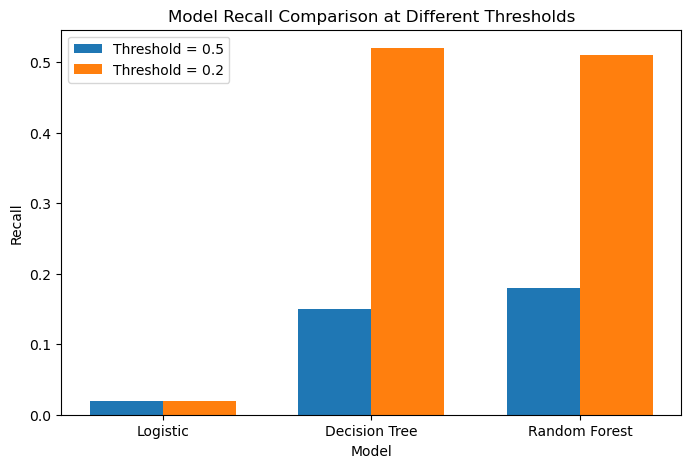

In [ ]:
# Compare recall at different thresholds for all models
data = {
    "Model": ["Logistic", "Decision Tree", "Random Forest"],
    "Recall_0.5": [0.02, 0.15, 0.18],
    "Recall_0.2": [0.02, 0.52, 0.51]
}

df = pd.DataFrame(data)

# Create a bar plot to compare recall at different thresholds
x = np.arange(len(df["Model"]))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, df["Recall_0.5"], width, label="Threshold = 0.5")
plt.bar(x + width/2, df["Recall_0.2"], width, label="Threshold = 0.2")

plt.xticks(x, df["Model"])
plt.ylabel("Recall")
plt.xlabel("Model")
plt.title("Model Recall Comparison at Different Thresholds")
plt.legend()
plt.show()